# <span style="color:green"> Numerical Simulation Laboratory (NSL) </span>
## <span style="color:blue">  Numerical exercises 4</span>

### **Exercise 04.1**

In Statistical Mechanics the Maxwell–Boltzmann distribution (<a href="https://en.wikipedia.org/wiki/Maxwell%E2%80%93Boltzmann_distribution" target="_blank">Link Wikipedia</a>) is a probability distribution used for describing particle speeds in idealized gases. However, rarefied gases at ordinary temperatures behave very nearly like an ideal gas and the Maxwell–Boltzmann speed distribution is an excellent approximation for such gases. In order to sample th

For a 3D system its formula is:
$$p(v,T) = \left( \frac{m}{2\pi k_B T} \right)^{3/2} 4\pi v^2 e^{-\frac{m v^2}{2 k_B T}}$$

By using LJ reduced units (Lenght: $\sigma$; Energy: $\epsilon$; Mass: the mass, $m$, of the particles; Temperature: $\epsilon/k_B$; velocity: $\sqrt{\epsilon/m}$) its form becomes:
$$p(v^*,T^*) = \frac{1}{(2\pi T^*)^{3/2}} 4\pi (v^*)^2 e^{-\frac{(v^*)^2}{2 T^*}}$$

The NSL_SIMULATOR code already computes the total (internal) energy per particle, $E/N$, the potential energy per particle, $U/N$, the kinetic energy per particle, $K/N$, the temperature, $T$, and the pressure, $P$.

<span style="color:red">Include the calculation of the Maxwell–Boltzmann distribution, $p(v^*,T^*)$, inside your Molecular Dynamics code by using data blocking to obtain single block averages, progressive average values and progressive uncertainties for $p(v^*,T^*)$.</span>

Remember that, the Maxwell–Boltzmann distribution, $p(v^*,T^*)$, can be approximately computed as a **normalized histogram** on an appropriate interval $\left[ 0, v_{max}\right]$ and chosing the number of bins into which you want to divide this interval.





### Exercise 04.2

By means of your upgraded code, <span style="color:red">perform MD simulations via a Lennard-Jones model</span> ( e.g. Argon parameters: $\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- gas phase: $\rho^\star = 0.05$, $T^\star \sim  2.0$ (cut-off radius: $r_c = 5.0$)

starting from a <span style="color:red">**very low entropic** initial configuration</span>:
1. initial **particle positions**: <span style="color:red">fcc crystal occupying half of the simulation box in each dimension</span>
2. initial **velocity distribution**: <span style="color:red">$p_\delta(v^*,T^*) = \delta\left( v^* - v_{T^*}\right)$</span> where $v_{T^*}$ is suitably connected to $T^*$. For example, this condition could be obtained by imposing that every particle has an initial velocity $\pm v_{T^*}$ for **only one** of its velocity components: $v_x$, $v_y$, $v_z$.

The goal is to show that, by evolving such initial condition via a Molecular Dynamics simulation, the velocity distribution tends to approximate the Maxwell–Boltzmann distribution.

- **Produce some pictures that show this convergence**
- The evolution of the system moves towards the increasing of entropy (more homeogeneous configuration of particles)? What would you find by changing the direction of time? Comment on these aspects in your jupyter-notebook

**Note that** the MD simulation will conserve the total energy; thus the kinetic energy and the temperature are not constant of motion ... the comparison should be done with $p(v^*,T^*_{\rm eff})$ where $T^*_{\rm eff}$ is the effective temperature obtained once the system has been equilibrated.

### Exercise 04.3

Starting from the **final states** of two MD simulations of the system in Exercise 04.2, one with about $5\times 10^3$ time-steps the other with about $5\times 10^4$ time-steps, by changing the direction of time (e.g. by inverting the final velocities, i.e. ... ), try to return back to the very low entropic initial configuration of Exercise 04.2. Is this possible? (for example, one can monitor the behavior of the average **potential energy** and the average **temperature** in **each block** as a function of time going **in both directions**. Show some picture and comment on what you find in your jupyter-notebook.

# **Submission**

### **Exercise 04.1 - Maxwell Boltzmann sampling**

#### **Verlet algorithm and code pipeline**

In the files `NSL_SIMULATOR/SOURCE/particle.cpp` and `NSL_SIMULATOR/SOURCE/system.cpp` are implemented the functions to set up the Molecular Dynamics simulation. 
The simulated system isn't an idealized gas, in fact it is a real gas since we simulate the particle interaction via the function `double System ::Force(int i, int dim)` given by the Lennard-Jones pair interaction potential:
$
\begin{equation}
 V_{LJ}(r_{ij}) = 4\epsilon\left(\frac{1}{(r_{ij}^{12})^*} - \frac{1}{(r_{ij}^{6})^*}\right)
\end{equation}
$
if $r< r_{cut}$ else $V_{LJ}(r_{ij}) = 0$. Being that the $V_{LJ}$ term isn't particularly significant since the density of the simulated gas is small, the velocity probability distribution settles to a Maxwell-Boltzmann distribution. The Lennard-Jones potential is fundamental in sampling the Maxwell–Boltzmann distribution since to implement the Verlet algorithm it is necessary to include the acceleration (thus the force) acting on each particle. The Verlet algorithm is a numerical method used to integrate the equations of motion in Molecular Dynamics simulations. It can be derived from the Taylor expansion of the position of a particle at time $t+\delta t$ and $t-\delta t$:
$\begin{equation}
\mathbf{r}(t+\delta t) = \mathbf{r}(t) + \mathbf{v}(t)\delta t + \frac{1}{2}\mathbf{a}(t)\delta t^2 + O(\delta t^3) \text{ and } \mathbf{r}(t-\delta t) = \mathbf{r}(t) - \mathbf{v}(t)\delta t + \frac{1}{2}\mathbf{a}(t)\delta t^2 + O(\delta t^3)
\end{equation}
$
Which yields:
$\begin{equation}
\mathbf{r}(t+\delta t) = 2\mathbf{r}(t) - \mathbf{r}(t-\delta t) +(\delta t)^2 \mathbf{a}(t) + O(\delta t^4)
\end{equation}
$
(the third order terms simplify since they have opposite signs). Thus, knowing the current and previous positions of the particle and the force acting on it allow to calculate it's following position. Clearly the algorithm can be calculated for the velocity also which satisfies the following equation:
$\begin{equation}
\mathbf{v}(t) = \frac{\mathbf{r}(t+\delta t) - \mathbf{r}(t - \delta t)}{2 \delta t} + O(\delta t^2)
\end{equation}$
These functions are implemented in `void System::Verlet()` which is used in `void System::step()`. The NSL_SIMULATOR requires to initialize the system and all measurable properties before evolving by using `void System ::initialize()` and `void System ::initialize_properties()`. `void System ::initialize()` reads the information from `INPUT/input.dat` and saves it in `OUTPUT/output.dat` and in the correct variables, on the other hand `void System ::initialize_properties()` prepares the output files for the properties that are going to be measured in the simulation, written in `INPUT/properties.dat`.


**NOTE**: in the code all properties are saved in a variable of type `vec` of the Armadillo library and for each property in `void System ::initialize_properties()` the indexes of the properties are initialized, in this way the `vec measurement` is given the correct size to fit all desired properties (which include the number of bins for measuring the Maxwell-Boltzmann distribution).

The datablocking is already implemented in the functions `void System ::measure()`, `void System ::averages(int blk)` and `double System ::error(double acc, double acc2, int blk)` and in the output files the data is printed in the following way: block average, cumulative average and error relative to the cumulative average. The number of blocks and number of steps per block are input variables written in `INPUT/input.dat`.

#### **$p(v)$ code**
To sample $p(v)$ the first thing to do is modify `void System ::initialize_properties()` since, according to the number of blocks (written in `properties.dat`), it is necessary to create the same amount of files 
All the histograms are saved in the following directory:
`OUTPUT/POFV`. In each file I saved respectively, in order of colums:
1. the number of bins
2. average probability of particles per bin for that block
3. average probability of particles per bin calculated by doing the data blocking on all the previous blocks
4. error of the data blocking calculation

A snippet of the code to initialize the files to sample $p(v)$:
```cpp
    //...
      else if (property == "POFV")
      {
        if (_sim_type > 0)
        {
          cerr << "PROBLEM: DOES NOT MAKE SENSE COMPUTING POFV FOR MC" << endl;
          exit(EXIT_FAILURE);
        }
        for (int i = 0; i < _nblocks; i++)
        {
          ofstream coutpv("../OUTPUT/POFV/pofv" + to_string(i + 1) + ".dat");
          coutpv << setw(12) << "#Bin   " << setw(12) << "#Single_Part_Bin  " << setw(12) << "#Global_Part_Bin  " << setw(12) << "Error_Global_Calculation";
          coutpv.close();
        }
        input >> _n_bins_v;
        _nprop += _n_bins_v;
        _bin_size_v = 4.0 * _temp / (double)_n_bins_v;
        _measure_pofv = true;
        _index_pofv = index_property;
        cout << _index_pofv << endl;
        cout << _n_bins_v << endl;
        index_property += _n_bins_v;
      }
      //...
```
To fill the bins modified the function `void System::measure()` by adding the following code:
```cpp
//...
  if (_measure_pofv)
  {
    for (int i = 0; i < _npart; i++)
    {
    //calculate the module of the velocity of each particle
      double mod_velocity = sqrt(dot(_particle(i).getvelocity(),
                                     _particle(i).getvelocity()));

      // Calcolo diretto del bin
      int j = (int)(mod_velocity / _bin_size_v);

      // Controllo limiti
      if (j >= 0 && j < _n_bins_v)
      {
        _measurement(_index_pofv + j)++;
      }
    }
  }
  //...
```
  and the results of the simulation are saved in the following way in `void System ::averages(int blk)`:
```cpp
  if (_measure_pofv)
  {
    //normalize over the number of particles and bin size
    for (int i = 0; i < _n_bins_v; i++)
    {
      _average(_index_pofv + i) /= (double(_npart) * _bin_size_v);
    }
  }
  // ... and ...
  if (_measure_pofv)
  {
    coutf.open("../OUTPUT/POFV/pofv" + to_string(blk) + ".dat", ios::app);
    for (int i = 0; i < _n_bins_v; i++)
    {
      average = _average(_index_pofv + i);
      sum_average = _global_av(_index_pofv + i);
      sum_ave2 = _global_av2(_index_pofv + i);

      coutf << setw(12) << i + 1
            << setw(12) << average
            << setw(12) << sum_average / double(blk)
            << setw(12) << this->error(sum_average, sum_ave2, blk) << endl;
    }
    coutf.close();
  }
```
The data is saved in this way in order to find as a plotted result a normalized distibution with $\int_0^\infty p(v)dv = 1$

### **Exercise 04.2 - The Delta Distribution**

By means of your upgraded code, <span style="color:red">perform MD simulations via a Lennard-Jones model</span> ( e.g. Argon parameters: $\sigma = 0.34$ nm, $\epsilon/k_B = 120$ K, $m=39.948$ amu) in the following conditions:
- gas phase: $\rho^\star = 0.05$, $T^\star \sim  2.0$ (cut-off radius: $r_c = 5.0$)

starting from a <span style="color:red">**very low entropic** initial configuration</span>:
1. initial **particle positions**: <span style="color:red">fcc crystal occupying half of the simulation box in each dimension</span>
2. initial **velocity distribution**: <span style="color:red">$p_\delta(v^*,T^*) = \delta\left( v^* - v_{T^*}\right)$</span> where $v_{T^*}$ is suitably connected to $T^*$. For example, this condition could be obtained by imposing that every particle has an initial velocity $\pm v_{T^*}$ for **only one** of its velocity components: $v_x$, $v_y$, $v_z$.

The goal is to show that, by evolving such initial condition via a Molecular Dynamics simulation, the velocity distribution tends to approximate the Maxwell–Boltzmann distribution.

- **Produce some pictures that show this convergence**
- The evolution of the system moves towards the increasing of entropy (more homeogeneous configuration of particles)? What would you find by changing the direction of time? Comment on these aspects in your jupyter-notebook

**Note that** the MD simulation will conserve the total energy; thus the kinetic energy and the temperature are not constant of motion ... the comparison should be done with $p(v^*,T^*_{\rm eff})$ where $T^*_{\rm eff}$ is the effective temperature obtained once the system has been equilibrated.


#### **Code structure**
To make the particles occupy initially only half the volume of the entire box in `void System::read_configuration()`, specifically I wrote:
```cpp
    //...
    for (int i = 0; i < _npart; i++)
    {
      cinf >> particle >> x >> y >> z; // units of coordinates in conf.xyz is _side
      _particle(i).setposition(0, this->pbc(_side(0) * x/2.0, 0));
      _particle(i).setposition(1, this->pbc(_side(1) * y/2.0, 1));
      _particle(i).setposition(2, this->pbc(_side(2) * z/2.0, 2));
      _particle(i).acceptmove(); // _x_old = _x_new
    }
    //...
```
To enforce the second condition, which means imposing that every particle has to have an initial velocity $\pm v_{T^*}$ for **only one** of its velocity components: $v_x$, $v_y$, $v_z$, I modificed the function `void System::initialize_velocities()`
```cpp
  { // TO BE TEMPORARILY CHANGED IN EXERCISE 4
    vec vx(_npart), vy(_npart), vz(_npart);
    vec sumv(_ndim); // velocity of the centre of mass
    sumv.zeros();

    // fixed module of velocity
    double _v_fixed = sqrt(3 * _temp);

    for (int i = 0; i < _npart; i = i + 2)
    {
      // choose direction and verse
      int direction = _rnd.one_two_three();
      int up_down = _rnd.up_or_down();
      //initialize the velocities in this way so I should cancel out all contributions
      if (direction == 0)
      {
        vx(i) = up_down * _v_fixed;
        vx(i + 1) = -up_down * _v_fixed;
      }
      else if (direction == 1)
      {
        vy(i) = up_down * _v_fixed;
        vy(i + 1) = -up_down * _v_fixed;
      }
      else if (direction == 2)
      {
        vz(i) = up_down * _v_fixed;
        vz(i+1) = - up_down* _v_fixed;
      }
      sumv(0) += vx(i) + vx(i+1);
      sumv(1) += vy(i) + vy(i+1);
      sumv(2) += vz(i) + vz(i+1);
    }
    for (int idim = 0; idim < _ndim; idim++)
      sumv(idim) = sumv(idim) / double(_npart);
    double sumv2 = 0.0, scalef;
    for (int i = 0; i < _npart; i++)
    {
      vx(i) = vx(i) - sumv(0);
      vy(i) = vy(i) - sumv(1);
      vz(i) = vz(i) - sumv(2);
      sumv2 += vx(i) * vx(i) + vy(i) * vy(i) + vz(i) * vz(i);
    }
    sumv2 /= double(_npart);
    scalef = sqrt(3.0 * _temp / sumv2); // velocity scale factor
    for (int i = 0; i < _npart; i++)
    {
      _particle(i).setvelocity(0, vx(i) * scalef);
      _particle(i).setvelocity(1, vy(i) * scalef);
      _particle(i).setvelocity(2, vz(i) * scalef);
    }
    for (int i = 0; i < _npart; i++)
    {
      xold = this->pbc(_particle(i).getposition(0, true) - _particle(i).getvelocity(0) * _delta, 0);
      yold = this->pbc(_particle(i).getposition(1, true) - _particle(i).getvelocity(1) * _delta, 1);
      zold = this->pbc(_particle(i).getposition(2, true) - _particle(i).getvelocity(2) * _delta, 2);
      _particle(i).setpositold(0, xold);
      _particle(i).setpositold(1, yold);
      _particle(i).setpositold(2, zold);
    }
  }
```

The video `delta_animation.mp4` was generated by saving the configuration every $5$ steps over a total of $2000$ steps, in the provided gas phase conditions. 
The plots below however were calculated over $20000$ total steps and every $100$ steps a block was calculated. Below are reported the plots for the kinetic, potential and total energy. 

To sample the Maxwell-Boltzmann distribution I decided to equilibrate the system with a total of $2000$ time steps and then sample the Boltzmann distribution over a total of $50^4$ times other steps and every 10 time steps I calculated a datablock. 


In [5]:
from IPython.display import Video

Video("IMAGES/delta_animation.mp4", width=640)

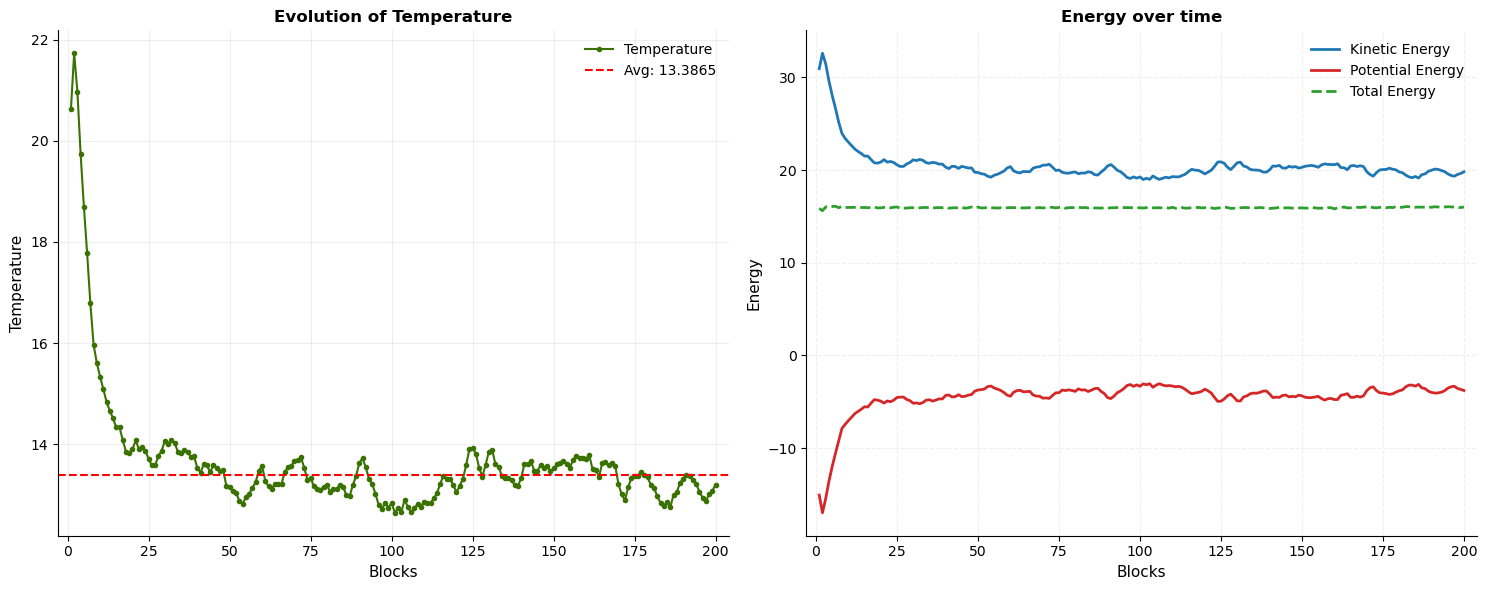

In [6]:
#Plot of evolution of temperature

import numpy as np
import matplotlib.pyplot as plt

# --- 1. Caricamento Dati ---
file_temp = "OUTPUT.2/temperature.dat"
file_kin = "OUTPUT.2/kinetic_energy.dat"
file_pot = "OUTPUT.2/potential_energy.dat"

temp_data = np.loadtxt(file_temp)
kin_data = np.loadtxt(file_kin)
pot_data = np.loadtxt(file_pot)

x_temp, y_temp = temp_data[:, 0], temp_data[:, 1]
x_kin, y_kin = kin_data[:, 0], kin_data[:, 1]
x_pot, y_pot = pot_data[:, 0], pot_data[:, 1]

# --- 2. Calcolo Media Temperatura (dal blocco 75) ---
tot = len(y_temp)
if tot > 125:
    media_temp = np.mean(y_temp[125:])
else:
    media_temp = np.mean(y_temp)

# --- 3. Creazione Figura con 2 Subplot ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- PLOT 1: TEMPERATURA (Sinistra) ---
color_temp = "#3a7202"
ax1.plot(x_temp, y_temp, 'o-', markersize=3, linewidth=1.5, color=color_temp, label="Temperature")
ax1.axhline(y=media_temp, color='r', linestyle='--', label=f'Avg: {media_temp:.4f}')

ax1.set_xlabel("Blocks", fontsize=11)
ax1.set_ylabel("Temperature", fontsize=11)
ax1.set_title("Evolution of Temperature", fontsize=12, fontweight='bold')
ax1.grid(alpha=0.2)
ax1.legend(frameon=False)
ax1.margins(x=0.02)

# Pulizia spine
for spine in ["top", "right"]:
    ax1.spines[spine].set_visible(False)

# --- PLOT 2: ENERGIE (Destra) ---
color_kin = "#1f77b4"
color_pot = "#d62728"
color_tot = "#2ca02c"

ax2.plot(x_kin, y_kin, label="Kinetic Energy", linewidth=2, color=color_kin)
ax2.plot(x_pot, y_pot, label="Potential Energy", linewidth=2, color=color_pot)

# Energia totale
if len(x_kin) == len(x_pot):
    ax2.plot(x_kin, y_kin + y_pot, linestyle='--', linewidth=2, color=color_tot, label="Total Energy")

ax2.set_xlabel("Blocks", fontsize=11)
ax2.set_ylabel("Energy", fontsize=11)
ax2.set_title("Energy over time", fontsize=12, fontweight='bold')
ax2.grid(alpha=0.2, linestyle='--')
ax2.legend(frameon=False)
ax2.margins(x=0.02)

# Pulizia spine
for spine in ["top", "right"]:
    ax2.spines[spine].set_visible(False)

# --- 4. Finalizzazione ---
plt.tight_layout()
# Crea la cartella Images se non esiste per evitare errori al salvataggio
import os
if not os.path.exists('Images'): os.makedirs('Images')

plt.savefig("IMAGES/temperature_energy_combined.jpg")
plt.show()

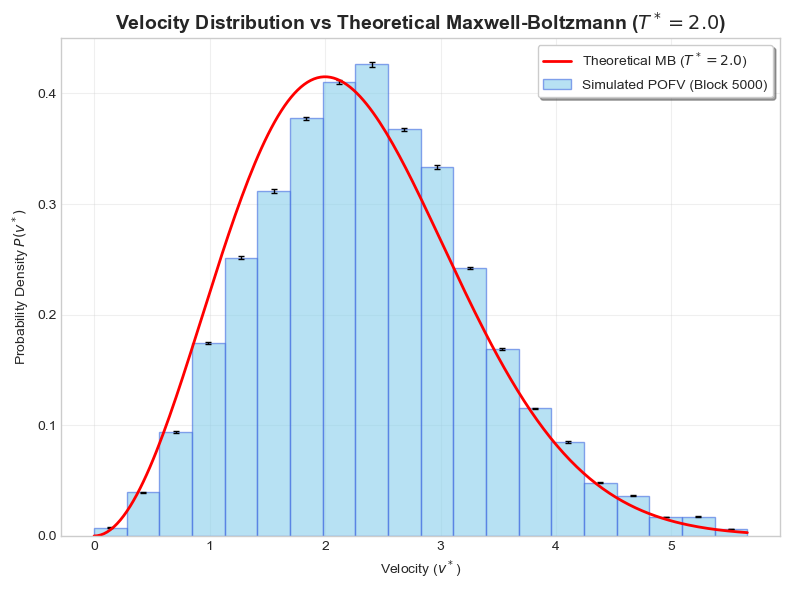

In [15]:
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# Scegli il file/blocco che vuoi analizzare (es. 1000)
block_number = 5000
filepath = f"NSL_SIMULATOR.2/OUTPUT/POFV/pofv{block_number}.dat"

# --- PARAMETRI TEORICI ---
T_star = 2.0  # Temperatura teorica fissata
max_v = 4.0 * np.sqrt(T_star)  

try:
    # Caricamento dati
    data = np.loadtxt(filepath)
    bins = data[:, 0]
    p_v = data[:, 2]    # Densità di probabilità simulata
    err_v = data[:, 3]  # Errore associato
    
    # Converte il numero del bin nella velocità v corrispondente al centro del bin
    n_bins = len(bins)
    bin_size = max_v / n_bins
    v_sim = (bins - 0.5) * bin_size

    fig, ax = plt.subplots(figsize=(8, 6))

    # 1. Plot dei dati simulati come istogramma con barre d'errore
    ax.bar(
        v_sim, p_v, 
        width=bin_size,       
        yerr=err_v,           
        color='skyblue', 
        edgecolor='royalblue', 
        alpha=0.6,            
        error_kw={'ecolor': 'black', 'elinewidth': 1, 'capsize': 2},
        label=f"Simulated POFV (Block {block_number})"
    )

    # 2. Curva Teorica di Maxwell-Boltzmann con T* = 2.0 (senza fit)
    v_teorico = np.linspace(0, max_v, 200)
    term1 = 1.0 / (2.0 * np.pi * T_star)**1.5
    term2 = 4.0 * np.pi * (v_teorico**2)
    term3 = np.exp(-(v_teorico**2) / (2.0 * T_star))
    p_teorico = term1 * term2 * term3

    ax.plot(
        v_teorico, p_teorico, 
        color='red', linestyle='-', linewidth=2, 
        label=f"Theoretical MB ($T^* = {T_star}$)"
    )

    # Personalizzazione del grafico
    ax.set_title(f"Velocity Distribution vs Theoretical Maxwell-Boltzmann ($T^* = {T_star}$)", fontsize=14, fontweight='bold')
    ax.set_xlabel("Velocity ($v^*$)")
    ax.set_ylabel("Probability Density $P(v^*)$")
    ax.grid(True, alpha=0.3)
    ax.legend(frameon=True, shadow=True)
    
    plt.tight_layout()
    plt.savefig(f"IMAGES/pofv_theory_T2_block_{block_number}.jpg", dpi=300)
    plt.show()

except Exception as e:
    print(f"Errore: {e}")

#### **Comment**
To do this simulation I used a velocity ($v$) equal to $\sqrt{3T}$ where the direction and verse of the velocity for each particle was chosen casually. The more the system evolves the more it tends to follow the Maxwell-Boltzmann distribution, this is due to the fact the system reaches the equilibrium. We can definitely say that the system moves toward a state with greater entropy and therefore a more homogeneous distribution of particles both in velocity and space, this can be observed from the plot of the distribution of the velocities once the system has evolved. It is possible to see that the distribution of the module of the velocities tends to settle in the Maxwell Boltzman distribution. 

We can see that at the start of the simulation there is an increase of the Kinetic energy and therefore a decrease of the potential energy, further on the system reaches a state of equilibrium and the values of energy don't vary significantly. There is a slight change in the total energy at the beginning of the simulation because of how the Verlet algorithm works (precision of the order $O(t^3)$).

### **Exercise 04.3 - Time inversion**
Answer to the last question of exercise 4.2: you would expect that the time evolution would be simply inverted, like rewinding a film, since Verlet is a deterministic algorithm therefore we can invert the trajectory without any problems and reach the initial configuration of the previous exercise. The aim of this excercise is to verify this proposition and if this doesn't occur, try to understand why this doesn't happen. To invert the time evolution we use use the data in the files `config-1.xyz` and `config.xyz` but swap by placing in `particle(i)._xold` the values present in the file `config.xyz` and an analogous procedure for `particle(i)._x`. In this way we invert the direction of the velocity.


The result of these calculations are saved in `5K` and `50K`. 
The simulation was done for 500 blocks of 10 steps and for 5000 blocks of 10 steps.
   

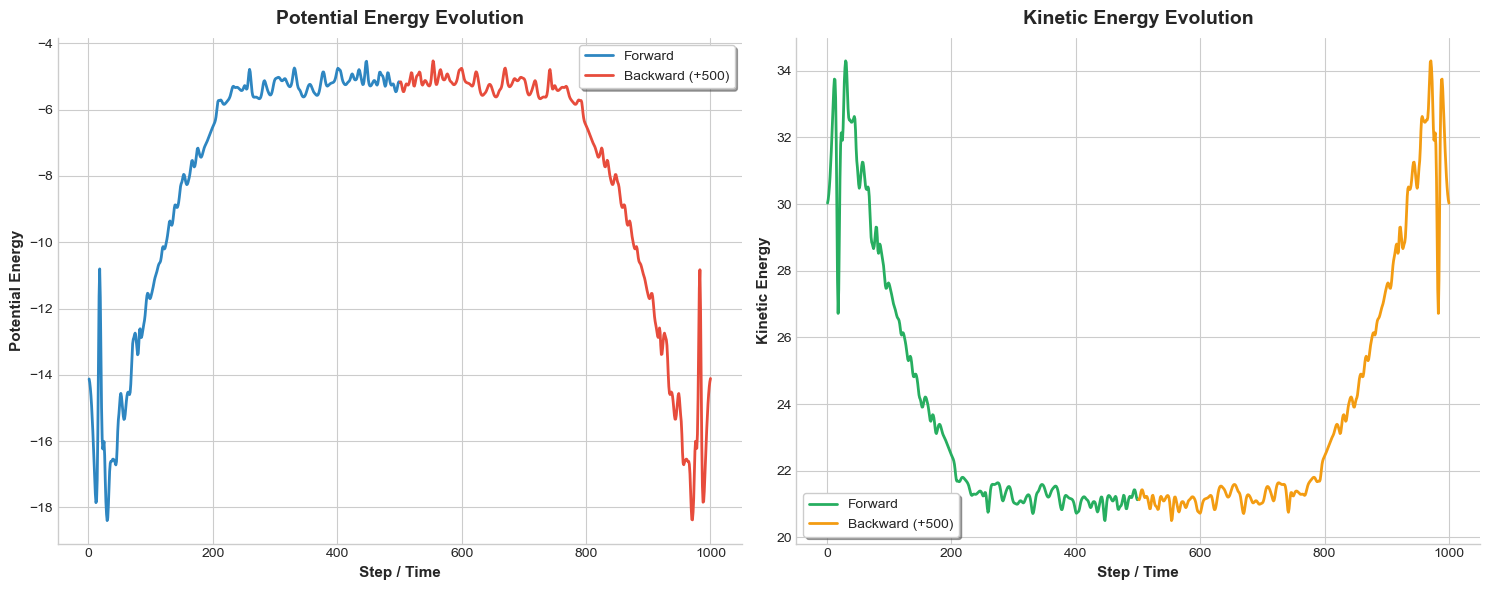

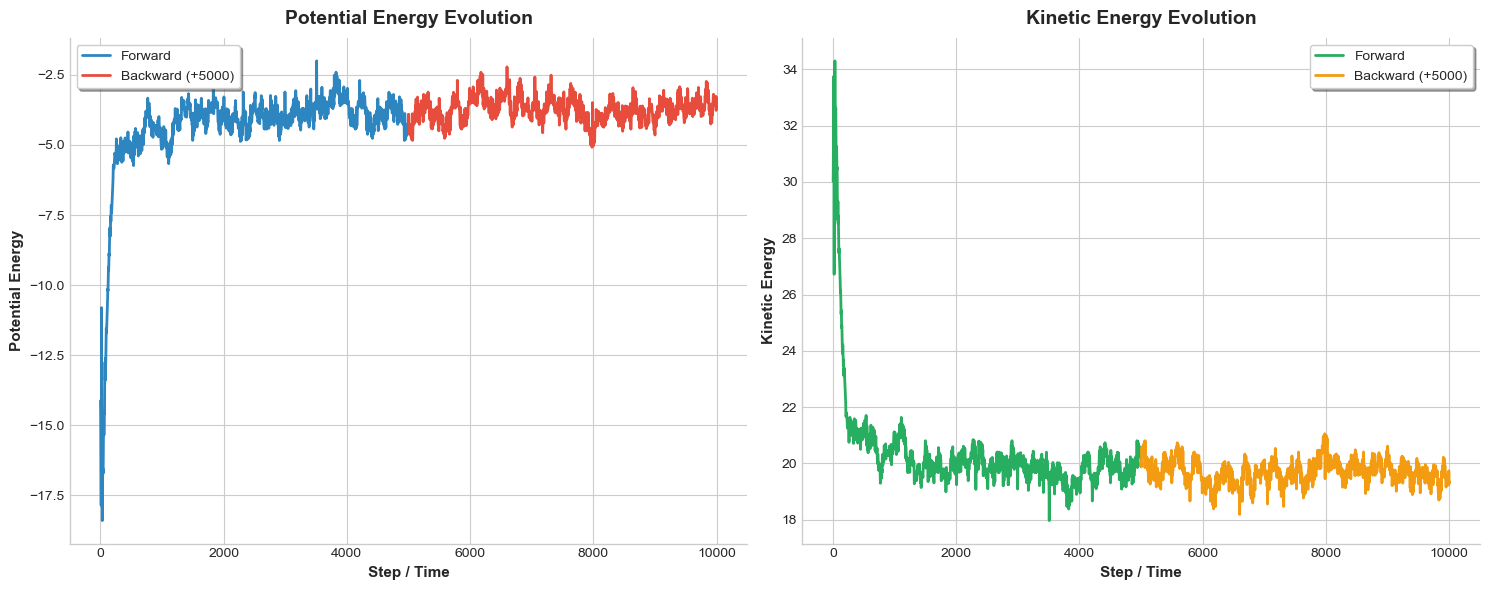

In [14]:
import numpy as np
import matplotlib.pyplot as plt

def plot_energy_comparison(folder_prefix, shift_value, output_filename):
    """
    Funzione per caricare e plottare il confronto dell'energia potenziale 
    e cinetica (Forward vs Backward) in base alla configurazione.
    """
    # 1. Set the style
    plt.style.use('seaborn-v0_8-whitegrid')

    # 2. Load data: Potential Energy
    pot_forward = np.loadtxt(f'{folder_prefix}/DATI_ANDATA/potential_energy.dat')
    pot_backward = np.loadtxt(f'{folder_prefix}/DATI_RITORNO/potential_energy.dat')

    # 3. Load data: Kinetic Energy
    kin_forward = np.loadtxt(f'{folder_prefix}/DATI_ANDATA/kinetic_energy.dat')
    kin_backward = np.loadtxt(f'{folder_prefix}/DATI_RITORNO/kinetic_energy.dat')

    # 4. Create the figure with 2 subplots side-by-side (1 row, 2 columns)
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

    # ==========================================
    # PLOT 1 (Left): POTENTIAL ENERGY
    # ==========================================
    ax1.plot(pot_forward[:, 0], pot_forward[:, 1], label='Forward', color='#2E86C1', linewidth=2)
    ax1.plot(pot_backward[:, 0] + shift_value, pot_backward[:, 1], label=f'Backward (+{shift_value})', color='#E74C3C', linewidth=2)

    ax1.set_title('Potential Energy Evolution', fontsize=14, fontweight='bold', pad=10)
    ax1.set_xlabel('Step / Time', fontsize=11, fontweight='bold')
    ax1.set_ylabel('Potential Energy', fontsize=11, fontweight='bold')
    ax1.legend(frameon=True, shadow=True)

    # Clean up borders
    ax1.spines['top'].set_visible(False)
    ax1.spines['right'].set_visible(False)

    # ==========================================
    # PLOT 2 (Right): KINETIC ENERGY
    # ==========================================
    ax2.plot(kin_forward[:, 0], kin_forward[:, 1], label='Forward', color='#27AE60', linewidth=2)
    ax2.plot(kin_backward[:, 0] + shift_value, kin_backward[:, 1], label=f'Backward (+{shift_value})', color='#F39C12', linewidth=2)

    ax2.set_title('Kinetic Energy Evolution', fontsize=14, fontweight='bold', pad=10)
    ax2.set_xlabel('Step / Time', fontsize=11, fontweight='bold')
    ax2.set_ylabel('Kinetic Energy', fontsize=11, fontweight='bold')
    ax2.legend(frameon=True, shadow=True)

    # Clean up borders
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    # 5. Optimize layout, save and display
    plt.tight_layout()
    plt.savefig(output_filename, dpi=300, bbox_inches='tight')
    plt.show()


# ==========================================
# Esecuzione per la configurazione 5K
# ==========================================
plot_energy_comparison(
    folder_prefix='5K', 
    shift_value=500, 
    output_filename='IMAGES/energy_comparison.png')
    
# ==========================================
# Esecuzione per la configurazione 50K
# ==========================================
plot_energy_comparison(
    folder_prefix='50K', 
    shift_value=5000, 
    output_filename='IMAGES/energy_comparison_50K.png'
)



#### **Comment**

For the simulation with $N_{steps} = 5000$ the straight-forward simulation and the time inverted one are completelly simmetrical, this is the result that we would expect because the `Verlet()` is a deterministic algorithm and therefore the time inversion of itself is as we would expect simply analogous to rewinding the video tape. On the other hand the simulation with $N_{steps} = 50000$, since the algorithm does so many steps it isn't able to conserve a perfect accuracy, after $6000$ steps it loses its accuracy and the particles start to follow a new trajectory different from the initial one. This can be clearly observed since in the initial dynamic we observe a peak value of the potential energy at around $3500$ steps, if the dynamic had been symmetrical w.r.t time inversion we should have observed another peak at $t \approx 7000$ but that isn't the case. 

When the information of the initial state is lost it is possible to see that the MD simulation settles in a state of greater entropy, therefore a more caotic and random situation than the initial one. 